# Klasifikasi Suara Burung: EfficientNet-B3 + GRU (V6 — Log-Mel Spectrogram)
**Referensi:** Baowaly et al. (2024)

- Ekstraksi fitur: Log-Mel Spectrogram → **Log-Mel Spectrogram**
- Channel R: Log-Mel (energi ternormalisasi adaptif)
- Loss: CategoricalFocalCrossentropy (alpha=0.25, gamma=2.0)
- Auto-Checkpoint ke Google Drive

In [ ]:
# ============================================================
# SEL 1: IMPORT LIBRARY & MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
import zipfile, os, random
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB3
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

drive.mount('/content/drive')
print('GPU aktif:', tf.config.list_physical_devices('GPU'))
print('TensorFlow:', tf.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU aktif: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow: 2.20.0


In [ ]:
# ============================================================
# SEL 2: EKSTRAK DATASET LOG-MEL SPECTROGRAM
# ============================================================
zip_path = '/content/drive/MyDrive/Skripsi/dataset_spectrograms.zip'
extract_path = '/content/dataset'

if not os.path.exists(extract_path):
    print('Mengekstrak dataset Log-Mel Spectrogram...')
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        for member in zip_ref.namelist():
            fixed_name = member.replace('\\', '/')
            target_path = os.path.join(extract_path, fixed_name)
            if fixed_name.endswith('/'):
                os.makedirs(target_path, exist_ok=True)
            else:
                os.makedirs(os.path.dirname(target_path), exist_ok=True)
                with zip_ref.open(member) as src, open(target_path, 'wb') as dst:
                    dst.write(src.read())
    print('Ekstrak selesai!')
else:
    print('Dataset sudah terekstrak.')

Dataset sudah terekstrak.


In [ ]:
# ============================================================
# SEL 3: VERIFIKASI DATASET (SpecAugment sudah dilakukan di Lokal)
# ============================================================
for split in ['train', 'val', 'test']:
    p = f'/content/dataset/dataset_spectrograms/{split}'
    total = sum(len(os.listdir(os.path.join(p, d))) for d in os.listdir(p) if os.path.isdir(os.path.join(p, d)))
    print(f'Total gambar {split}: {total}')

Total gambar train: 52704
Total gambar val: 566
Total gambar test: 504


In [ ]:
# ============================================================
# SEL 4: MEMBACA DATASET
# PENTING: color_mode='rgb' (default) — JANGAN ubah ke grayscale!
# Karena kita menggunakan format RGB yang dihasilkan matplotlib colormap magma.
#   R = Log-Mel, G = Delta, B = Delta-Delta
# ============================================================
BATCH_SIZE = 32
IMG_SIZE = (300, 300)

train_dir = '/content/dataset/dataset_spectrograms/train'
val_dir   = '/content/dataset/dataset_spectrograms/val'
test_dir  = '/content/dataset/dataset_spectrograms/test'

print('[1/3] Membaca Data Train:')
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, shuffle=True, batch_size=BATCH_SIZE,
    image_size=IMG_SIZE, label_mode='categorical'
)
print('[2/3] Membaca Data Validasi:')
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir, shuffle=False, batch_size=BATCH_SIZE,
    image_size=IMG_SIZE, label_mode='categorical'
)
print('[3/3] Membaca Data Test:')
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, shuffle=False, batch_size=BATCH_SIZE,
    image_size=IMG_SIZE, label_mode='categorical'
)
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f'\nKelas: {class_names}')

[1/3] Membaca Data Train:
Found 52704 files belonging to 5 classes.
[2/3] Membaca Data Validasi:
Found 566 files belonging to 5 classes.
[3/3] Membaca Data Test:
Found 504 files belonging to 5 classes.

Kelas: ['Geopelia striata', 'Passer montanus', 'Pycnonotus aurigaster', 'Pycnonotus goiavier', 'Streptopelia chinensis']


In [ ]:
# ============================================================
# SEL 5: MEMBANGUN ARSITEKTUR
# EfficientNet-B3 + GRU (sama dengan V6)
# Input: 300x300x3 (RGB Image)
# ============================================================
def build_model(num_classes):
    inputs = layers.Input(shape=IMG_SIZE + (3,))

    base_model = EfficientNetB3(
        include_top=False,
        input_tensor=inputs,
        weights='imagenet'
    )
    base_model.trainable = False

    feat = base_model.output
    x = layers.Reshape((100, 1536))(feat)
    x = layers.GRU(256, return_sequences=False, name='gru_layer')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4, name='top_dropout')(x)
    outputs = layers.Dense(
        num_classes, activation='softmax', name='pred',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    )(x)

    model = models.Model(inputs, outputs, name='EfficientNetB3_GRU_v6_Log-Mel')
    return model

model = build_model(num_classes)
model.summary()

Model: "EfficientNetB3_GRU_v6_Log-Mel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 300, 300,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 300, 300,  │          7 │ rescaling_4[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 300, 300,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 12,163,636 (46.40 MB)

 Trainable params: 1,379,589 (5.26 MB)

 Non-trainable params: 10,784,047 (41.14 MB)

In [ ]:
# ============================================================
# SEL 6: FASE 1 - TRAINING KEPALA MODEL
# Focal Loss + Auto Checkpoint ke Google Drive
# ============================================================
import os
os.makedirs('/content/drive/MyDrive/Skripsi/Backup_Model_V6', exist_ok=True)

# --- AUTO-RESUME: Skip Fase 1 jika checkpoint sudah ada ---
FASE1_CKPT = '/content/drive/MyDrive/Skripsi/Backup_Model_V6/best_fase1.keras'

if os.path.exists(FASE1_CKPT):
    print('Checkpoint Fase 1 ditemukan! Memuat model dari Drive...')
    model = tf.keras.models.load_model(FASE1_CKPT)
    print('Model Fase 1 dimuat. SKIP training Fase 1.')
    # Buat dummy history untuk grafik
    class DummyHistory:
        history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
    history_p1 = DummyHistory()
else:
    steps_per_epoch = len(train_dataset)

    cosine_lr_p1 = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-3,
        decay_steps=steps_per_epoch * 30,
        alpha=1e-6
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_lr_p1),
        loss=tf.keras.losses.CategoricalFocalCrossentropy(
            alpha=0.25, gamma=2.0, label_smoothing=0.05
        ),
        metrics=['accuracy']
    )

    early_stopping_p1 = callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    )

    checkpoint_p1 = callbacks.ModelCheckpoint(
        filepath=FASE1_CKPT,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )

    print('FASE 1: MELATIH KEPALA MODEL...')
    history_p1 = model.fit(
        train_dataset, epochs=30,
        validation_data=val_dataset,
        callbacks=[early_stopping_p1, checkpoint_p1]
    )
    print('Fase 1 selesai!')

steps_per_epoch = len(train_dataset)

FASE 1: MELATIH KEPALA MODEL...
Epoch 1/30
1647/1647 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.6374 - loss: 0.1840
Epoch 1: val_accuracy improved from None to 0.74912, saving model to /content/drive/MyDrive/Skripsi/Backup_Model_V6/best_fase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Skripsi/Backup_Model_V6/best_fase1.keras
1647/1647 ━━━━━━━━━━━━━━━━━━━━ 473s 276ms/step - accuracy: 0.7352 - loss: 0.1257 - val_accuracy: 0.7491 - val_loss: 0.1153
Epoch 2/30
1647/1647 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.8545 - loss: 0.0759
Epoch 2: val_accuracy did not improve from 0.74912
1647/1647 ━━━━━━━━━━━━━━━━━━━━ 496s 273ms/step - accuracy: 0.8666 - loss: 0.0719 - val_accuracy: 0.7473 - val_loss: 0.1166
Epoch 3/30
1647/1647 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.8895 - loss: 0.0651
Epoch 3: val_accuracy improved from 0.74912 to 0.77032, saving model to /content/drive/MyDrive/Skripsi/Backup_Model_V6/best_fase1.keras

Epoch 3: finished saving model t

In [ ]:
# ============================================================
# SEL 7: FASE 2 - FINE-TUNING
# Focal Loss + Auto Checkpoint
# ============================================================
FASE2_CKPT = '/content/drive/MyDrive/Skripsi/Backup_Model_V6/best_fase2.keras'

if os.path.exists(FASE2_CKPT):
    print('Checkpoint Fase 2 ditemukan! Memuat model dari Drive...')
    model = tf.keras.models.load_model(FASE2_CKPT)
    print('Model Fase 2 dimuat. SKIP training Fase 2.')
    class DummyHistory2:
        history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
    history_p2 = DummyHistory2()
else:
    print('FASE 2: FINE-TUNING BADAN EFFICIENTNET...')

    model.trainable = True
    for layer in model.layers[:100]:
        layer.trainable = False
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    cosine_lr_p2 = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=5e-5,
        decay_steps=steps_per_epoch * 50,
        alpha=1e-7
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_lr_p2),
        loss=tf.keras.losses.CategoricalFocalCrossentropy(
            alpha=0.25, gamma=2.0, label_smoothing=0.05
        ),
        metrics=['accuracy']
    )

    early_stopping_p2 = callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10,
        restore_best_weights=True, verbose=1
    )

    checkpoint_p2 = callbacks.ModelCheckpoint(
        filepath=FASE2_CKPT,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )

    print('FASE 2: MELATIH BADAN MODEL...')
    history_p2 = model.fit(
        train_dataset, epochs=50,
        validation_data=val_dataset,
        callbacks=[early_stopping_p2, checkpoint_p2]
    )
    print('Fase 2 selesai!')

FASE 2: FINE-TUNING BADAN EFFICIENTNET...
FASE 2: MELATIH BADAN MODEL...
Epoch 1/50
1647/1647 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9579 - loss: 0.0434
Epoch 1: val_accuracy improved from None to 0.77562, saving model to /content/drive/MyDrive/Skripsi/Backup_Model_V6/best_fase2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Skripsi/Backup_Model_V6/best_fase2.keras
1647/1647 ━━━━━━━━━━━━━━━━━━━━ 469s 275ms/step - accuracy: 0.9639 - loss: 0.0414 - val_accuracy: 0.7756 - val_loss: 0.1135
Epoch 2/50
1647/1647 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.9693 - loss: 0.0395
Epoch 2: val_accuracy improved from 0.77562 to 0.78622, saving model to /content/drive/MyDrive/Skripsi/Backup_Model_V6/best_fase2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Skripsi/Backup_Model_V6/best_fase2.keras
1647/1647 ━━━━━━━━━━━━━━━━━━━━ 451s 274ms/step - accuracy: 0.9717 - loss: 0.0389 - val_accuracy: 0.7862 - val_loss: 0.1140
Epoch 3/50
1647/1647 ━━━━━━━━━━━━━

Evaluasi Final di Data Test:
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 320ms/step - accuracy: 0.8115 - loss: 0.1070

AKURASI FINAL: 81.15%
Loss Final   : 0.1070


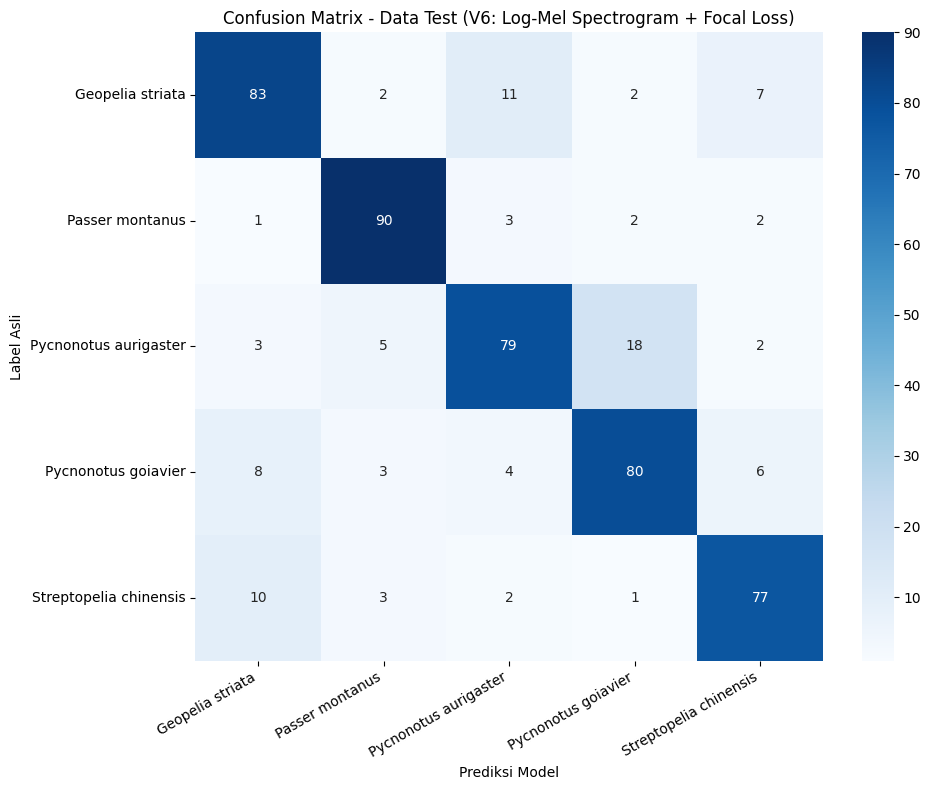

Confusion Matrix disimpan: /content/drive/MyDrive/Skripsi/confusion_matrix_v6.png

Classification Report:
                        precision    recall  f1-score   support

      Geopelia striata       0.79      0.79      0.79       105
       Passer montanus       0.87      0.92      0.90        98
 Pycnonotus aurigaster       0.80      0.74      0.77       107
   Pycnonotus goiavier       0.78      0.79      0.78       101
Streptopelia chinensis       0.82      0.83      0.82        93

              accuracy                           0.81       504
             macro avg       0.81      0.81      0.81       504
          weighted avg       0.81      0.81      0.81       504

Report disimpan: /content/drive/MyDrive/Skripsi/classification_report_v6.txt


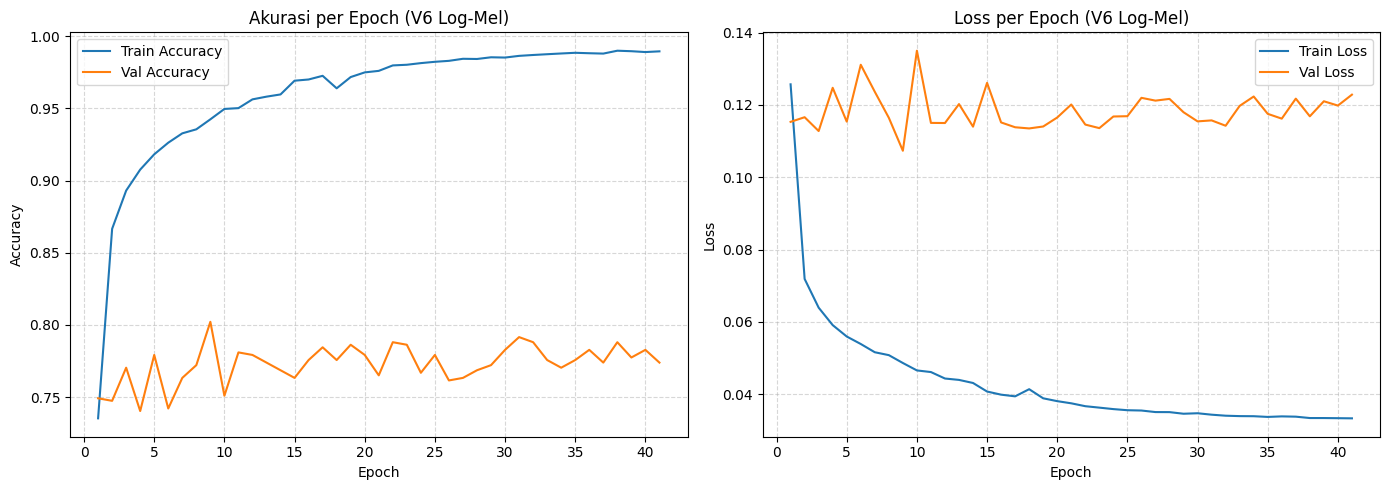

Grafik Training disimpan: /content/drive/MyDrive/Skripsi/training_history_v6.png

Model final disimpan: /content/drive/MyDrive/Skripsi/Model_Burung_B3_GRU_v6.keras
SELESAI! Semua hasil aman di Google Drive.


In [ ]:
# ============================================================
# SEL 8: EVALUASI LENGKAP + SIMPAN SEMUA HASIL KE DRIVE
# ============================================================

# --- A. Akurasi & Loss Final ---
print('Evaluasi Final di Data Test:')
test_loss, test_acc = model.evaluate(test_dataset, verbose=1)
print(f'\nAKURASI FINAL: {test_acc*100:.2f}%')
print(f'Loss Final   : {test_loss:.4f}')

# --- B. Confusion Matrix ---
y_pred_probs = model.predict(test_dataset, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_dataset])

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix - Data Test (V6: Log-Mel Spectrogram + Focal Loss)')
ax.set_ylabel('Label Asli')
ax.set_xlabel('Prediksi Model')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
cm_path = '/content/drive/MyDrive/Skripsi/confusion_matrix_v6.png'
plt.savefig(cm_path, dpi=300)
plt.show()
print(f'Confusion Matrix disimpan: {cm_path}')

# --- C. Classification Report ---
report = classification_report(y_true, y_pred, target_names=class_names)
print('\nClassification Report:')
print(report)

report_path = '/content/drive/MyDrive/Skripsi/classification_report_v6.txt'
with open(report_path, 'w') as f:
    f.write(f'Model: EfficientNet-B3 + GRU V6 (Log-Mel Spectrogram)\n')
    f.write(f'Ekstraksi: Log-Mel + Delta + Delta-Delta\n')
    f.write(f'Akurasi: {test_acc*100:.2f}%\nLoss: {test_loss:.4f}\n\n')
    f.write(report)
print(f'Report disimpan: {report_path}')

# --- D. Grafik Training ---
acc      = history_p1.history['accuracy']     + history_p2.history['accuracy']
val_acc  = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
loss_h   = history_p1.history['loss']         + history_p2.history['loss']
val_loss = history_p1.history['val_loss']     + history_p2.history['val_loss']

if len(acc) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ep_range = range(1, len(acc) + 1)

    axes[0].plot(ep_range, acc,     label='Train Accuracy')
    axes[0].plot(ep_range, val_acc, label='Val Accuracy')
    axes[0].set_title('Akurasi per Epoch (V6 Log-Mel)')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.5)

    axes[1].plot(ep_range, loss_h,   label='Train Loss')
    axes[1].plot(ep_range, val_loss, label='Val Loss')
    axes[1].set_title('Loss per Epoch (V6 Log-Mel)')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    graph_path = '/content/drive/MyDrive/Skripsi/training_history_v6.png'
    plt.savefig(graph_path, dpi=300)
    plt.show()
    print(f'Grafik Training disimpan: {graph_path}')
else:
    print('Grafik tidak dibuat karena kedua fase di-resume dari checkpoint.')

# --- E. Simpan Model Final ---
save_path = '/content/drive/MyDrive/Skripsi/Model_Burung_B3_GRU_v6.keras'
model.save(save_path)
print(f'\nModel final disimpan: {save_path}')
print('SELESAI! Semua hasil aman di Google Drive.')